In [3]:
import sys
sys.path.append('/Users/aidanmorson/Desktop/analysis/parkinsons/analysis')

In [4]:
from analysis.position_sd import get_neuron_positions, compute_nearest_neighbor_distances
from load_data.load_npz import load_spikedata
import os
import numpy as np
import matplotlib.pyplot as plt


In [5]:
sd24578_49 = load_spikedata('/Users/aidanmorson/Desktop/analysis/parkinsons/data-by-day/d49/24578_D49-6.zip')
sd24578_60 = load_spikedata('/Users/aidanmorson/Desktop/analysis/parkinsons/data-by-day/d60/24578_D60+6.zip')
sd24481_49 = load_spikedata('/Users/aidanmorson/Desktop/analysis/parkinsons/data-by-day/d49/24481_D49-6.zip')
sd24481_60 = load_spikedata('/Users/aidanmorson/Desktop/analysis/parkinsons/data-by-day/d60/24481_D60+6.zip')

In [6]:
full_list = [sd24481_49, sd24481_60, sd24578_49, sd24578_60]
full_names = [f"24481 D49: {sd24481_49.N} Units ", f"24481 D60: {sd24481_60.N} Units", f"24578 D49: {sd24578_49.N} Units", f"24578 D60: {sd24578_60.N} Units"]
full_colors = ["green", "lime", "royalblue", "cyan"]

In [8]:
def summarize_average_separation(sd_list, colors, dataset_names):
    """
    For each SpikeData in sd_list, compute the average distance for each neuron,
    then compute summary statistics (mean, median, variance, std, min, max).
    
    Parameters:
      sd_list : list of SpikeData
      dataset_names : list of str (same length as sd_list)
    
    Returns:
      summary_list : list of dict
         Each dict contains the dataset name plus the summary stats.
         e.g.:
         [
           {
             "dataset": "Dataset1",
             "N_neurons": 100,
             "mean": ...,
             "median": ...,
             "variance": ...,
             "std": ...,
             "min": ...,
             "max": ...
           },
           ...
         ]
    """
    summary_list = []
    
    for i, sd in enumerate(sd_list):
        dataset_name = dataset_names[i] if i < len(dataset_names) else f"Dataset_{i+1}"
        color = colors[i]
        
        # Get positions
        full_positions = get_neuron_positions(sd)
        valid_positions = np.array([pos for pos in full_positions if not np.allclose(pos, [0, 0])])
        if valid_positions.size == 0:
            print(f"No valid positions for dataset {dataset_name}, skipping.")
            summary_list.append({
                "dataset": dataset_name,
                "N_neurons": 0,
                "mean": np.nan,
                "median": np.nan,
                "variance": np.nan,
                "std": np.nan,
                "min": np.nan,
                "max": np.nan
            })
            continue
        
        # Compute average distance for each neuron
        dist_matrix = np.linalg.norm(valid_positions[:, None] - valid_positions, axis=2)
        np.fill_diagonal(dist_matrix, np.nan)
        avg_distances = np.nanmean(dist_matrix, axis=1)  # shape (N,)
        
        # Summary stats
        summary_dict = {
            "dataset": dataset_name,
            "colors": color,
            "N_neurons": len(avg_distances),
            "mean": float(np.nanmean(avg_distances)),
            "median": float(np.nanmedian(avg_distances)),
            "variance": float(np.nanvar(avg_distances)),
            "std": float(np.nanstd(avg_distances)),
            "min": float(np.nanmin(avg_distances)),
            "max": float(np.nanmax(avg_distances))
        }
        summary_list.append(summary_dict)
    
    return summary_list

def plot_variance_bar(summaries):
    """
    Given the list of summary dicts from summarize_average_separation(),
    plot a bar chart of variance vs. dataset.
    """
    dataset_labels = [s["dataset"] for s in summaries]
    variances = [s["variance"] for s in summaries]
    color=[s["colors"] for s in summaries]
    
    plt.figure(figsize=(8,6))
    x_pos = np.arange(len(dataset_labels))
    plt.bar(x_pos, variances, color=color)
    plt.xticks(x_pos, dataset_labels, rotation=45, ha='right')
    plt.ylabel("Variance of Avg Distances (µm^2)")
    plt.title("Variance of Average Separation")
    plt.tight_layout()
    plt.show()


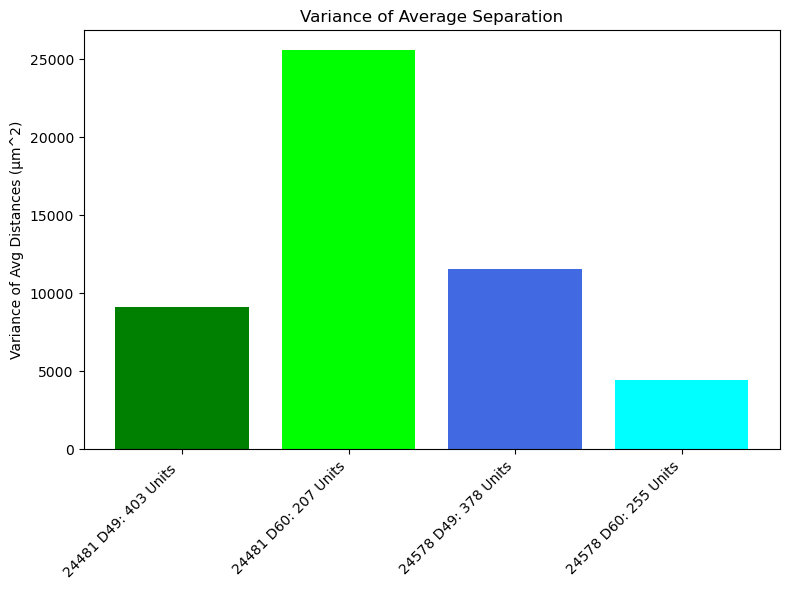

In [9]:
summaries_avg = summarize_average_separation(full_list, full_colors, full_names)
plot_variance_bar(summaries=summaries_avg)

In [10]:
def summarize_nn(sd_list, colors, dataset_names):
    """
    For each SpikeData in sd_list, compute the average distance for each neuron,
    then compute summary statistics (mean, median, variance, std, min, max).
    
    Parameters:
      sd_list : list of SpikeData
      dataset_names : list of str (same length as sd_list)
    
    Returns:
      summary_list : list of dict
         Each dict contains the dataset name plus the summary stats.
         e.g.:
         [
           {
             "dataset": "Dataset1",
             "N_neurons": 100,
             "mean": ...,
             "median": ...,
             "variance": ...,
             "std": ...,
             "min": ...,
             "max": ...
           },
           ...
         ]
    """
    summary_list_nn = []
    
    for i, sd in enumerate(sd_list):
        dataset_name = dataset_names[i] if i < len(dataset_names) else f"Dataset_{i+1}"
        color = colors[i]
        
        # Get positions
        full_positions = get_neuron_positions(sd)
        valid_positions = np.array([pos for pos in full_positions if not np.allclose(pos, [0, 0])])
        if valid_positions.size == 0:
            print(f"No valid positions for dataset {dataset_name}, skipping.")
            summary_list_nn.append({
                "dataset": dataset_name,
                "N_neurons": 0,
                "mean": np.nan,
                "median": np.nan,
                "variance": np.nan,
                "std": np.nan,
                "min": np.nan,
                "max": np.nan
            })
            continue
        
        # 2. Compute pairwise distances.
        nearest_neighbor = compute_nearest_neighbor_distances(valid_positions)

        
        # Summary stats
        summary_dict = {
            "dataset": dataset_name,
            "colors": color,
            "N_neurons": len(nearest_neighbor),
            "mean": float(np.nanmean(nearest_neighbor)),
            "median": float(np.nanmedian(nearest_neighbor)),
            "variance": float(np.nanvar(nearest_neighbor)),
            "std": float(np.nanstd(nearest_neighbor)),
            "min": float(np.nanmin(nearest_neighbor)),
            "max": float(np.nanmax(nearest_neighbor))
        }
        summary_list_nn.append(summary_dict)
    
    return summary_list_nn

def plot_variance_bar(summaries):
    """
    Given the list of summary dicts from summarize_average_separation(),
    plot a bar chart of variance vs. dataset.
    """
    dataset_labels = [s["dataset"] for s in summaries]
    variances = [s["variance"] for s in summaries]
    color = [s["colors"] for s in summaries]
    
    plt.figure(figsize=(8,6))
    x_pos = np.arange(len(dataset_labels))
    plt.bar(x_pos, variances, color=color)
    plt.xticks(x_pos, dataset_labels, rotation=45, ha='right')
    plt.ylabel("Variance of Nearest Neighbor Distances (µm^2)")
    plt.title("Variance of Nearest Neighbor")
    plt.tight_layout()
    plt.show()


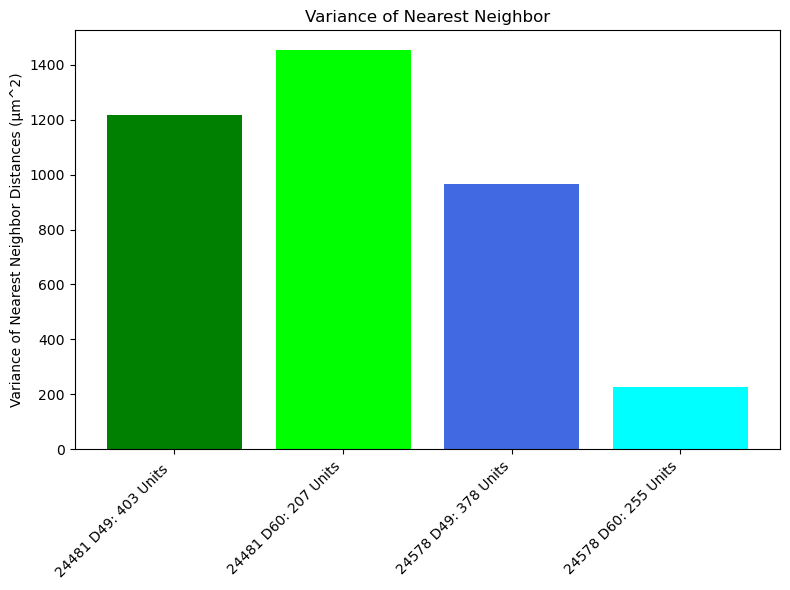

In [11]:
nn_summaries = summarize_nn(full_list, full_colors, full_names)
plot_variance_bar(summaries=nn_summaries)